## Week 4: NLP Disaster Tweets Kaggle Mini-Project

### Problem Description:

Using a Recurrent Neural Network model to classify texts, specifically Tweets as a disaster or not.

### 1. Import the necessary python libraries

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

import re
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.optimizers import Adam

### 2. Load Data

Get the path of the test and train datasets and read the csv test.csv and train.csv datasets. The first 5 rows of the train.csv are dsiplayed as well.

In [2]:
dataset_path = os.path.join(os.getcwd(), "dataset")
test_dataset_path = os.path.join(dataset_path, "test.csv")
train_dataset_path = os.path.join(dataset_path, "train.csv")

train_dataset = pd.read_csv(train_dataset_path)

display(train_dataset.head())

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


### 3. Exploratory Data Analysis (EDA)

First check for basic info about the training dataset, which shows that the dataset only has several columns such as "id", "keyword", "location", "text", and "target". The dataset also has 7613 rows of data.

In [3]:
train_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


Another form of EDA that can be perfomed is the describe() function that wil display some basic metrics/statistics. Some of these metrics include total row counts, mean, and standard deviation.

In [4]:
display(train_dataset.describe())

,id,target
count,7613.000000,7613.00000
mean,5441.934848,0.42966
std,3137.116090,0.49506
min,1.000000,0.00000
25%,2734.000000,0.00000
50%,5408.000000,0.00000
75%,8146.000000,1.00000
max,10873.000000,1.00000


Next check for any null values in the training dataset, by calling isna() and sum() on the trianing labels dataframe. The return of the function displays 61 for the "keyword" column and 2533 for the "location" column.

In [5]:
display(train_dataset.isna().sum())

id             0
keyword       61
location    2533
text           0
target         0
dtype: int64

After verifying that the two columns did indeed have some NaN values, display the non NaN values to see what type of information the columns provide. Upon further inspecting the columns the data provided by them will not necessarily will a deep learning model identifiy if a tweet is truely a disaster. As result this columns can be removed without effecting how will models will preform. 

In [6]:
display(train_dataset[["keyword", "location"]])
display(train_dataset.loc[train_dataset["keyword"].notna() & train_dataset["location"].notna(), ["keyword", "location"]])

,keyword,location
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN
...,...,...
7608,NaN,NaN
7609,NaN,NaN
7610,NaN,NaN
7611,NaN,NaN


,keyword,location
31,ablaze,Birmingham
32,ablaze,Est. September 2012 - Bristol
33,ablaze,AFRICA
34,ablaze,"Philadelphia, PA"
35,ablaze,"London, UK"
...,...,...
7575,wrecked,TN
7577,wrecked,#NewcastleuponTyne #UK
7579,wrecked,"Vancouver, Canada"
7580,wrecked,London


Next as part of the EDA, calculate the label distribution, and create a bar plot to visually dispaly the calculated distribution.The lable percentage is also calculated and displayed. Based off the label distribution bar plot and the label precentage, the labels are the most part balanced. There is a slight skew towards label 0 whihc is about 57.0%  but it is not high enough to be a problem during model training.

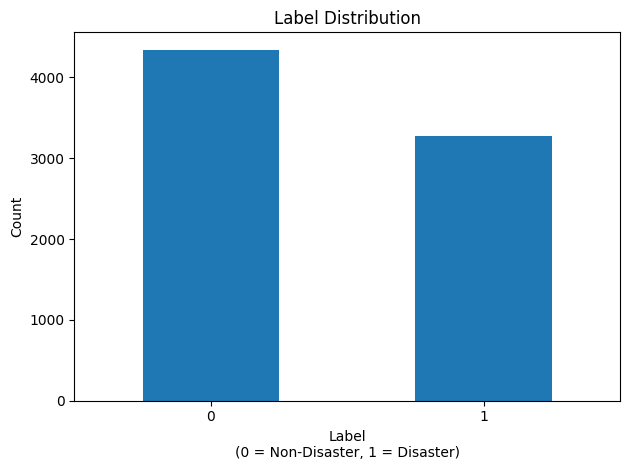

Label Percentage:


target
0    57.034021
1    42.965979
Name: count, dtype: float64

In [7]:
label_counts = train_dataset["target"].value_counts().sort_index()

plt.figure()
label_counts.plot(kind="bar")
plt.title("Label Distribution")
plt.xlabel("Label\n(0 = Non-Disaster, 1 = Disaster)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

label_percentage = (label_counts / label_counts.sum()) * 100
print(f"Label Percentage:")
display(label_percentage)

### 4. Data Preprocessing

For datapreocessing drop the columns with the NAN values. As well as clean and tokenize the raw text and map each word to a Glove embedding vector. This transforms texts into a numerical sequences that machine learning models can understand.

In [8]:
cols_to_drop = ["keyword", "location"]
cleaned_train = train_dataset.drop(columns=cols_to_drop)

display(cleaned_train.head())

cleaned_train.to_csv("cleaned_data.csv", index=False)

,id,text,target
0,1,Our Deeds are the Reason of this #earthquake M...,1
1,4,Forest fire near La Ronge Sask. Canada,1
2,5,All residents asked to 'shelter in place' are ...,1
3,6,"13,000 people receive #wildfires evacuation or...",1
4,7,Just got sent this photo from Ruby #Alaska as ...,1


Extract "x" features and and the "y" targets from the dataset.

In [9]:
texts = cleaned_train["text"].values
targets = cleaned_train["target"].values

Next prepare the raw tweets text data so that it can be used as an input for neural network model. The first step is to create seta max vocab size which will limit the vocabulary to 10,000 most common words in the dastset, and create a Tokenizer to convert words inot numerical representations. The fit_on_texts() method will update the tokenizer object based on the actually tweets text data. 

In [10]:
max_vocab_size = 10000
tokenizer = Tokenizer(num_words=max_vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)

Next the tweets text data needs to be converted into sequences. The texts_to_sequences() tokenizer function transforms each text into a sequence of integers, where each integer corresponds to a word's index inthe vocabulary. tokenizer.word_index stores a dictionary mapping for each word to its assigned interger index.

In [11]:
sequences = tokenizer.texts_to_sequences(texts)
word_index = tokenizer.word_index

After creating the sequences, some of the sequences might need some padding since the sequences are standardized  to the same length. For the purpose of this project the max lenght is set 100, and function pad_sequences() function is called to pad shart and long sequences.

In [12]:
max_len = 100
padded_sqequences = pad_sequences(sequences, maxlen=max_len, padding="post", truncating="post")

After pading the sequences the next step is to prepare the word embeddings. For this project a dimensionaliy for the embeddings is set to 100 and the empty dictionary is initialized to store the embeddings

In [13]:
embedding_dim = 100
embedding_index = {}

Next step is to start processing the texts into a matrix form. For project I opted to use GloVe strategy but instead of trainig a new local GloVe embeddeing with the tweets which is small when compared to the datasets used on pre-trained GloVe embeddings. So  the pre-trained [GloVe](https://nlp.stanford.edu/projects/glove/) that was used was provided by Standford University. The following code block loads the pre-trained Glove and and extracts the word and coefs to create a numpy array of 100 numberical features (embedding) and stores them inthe created embedding_matrix.

In [14]:
with open('glove.6B.100d.txt', encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embedding_index[word] = coefs

embedding_matrix = np.zeros((max_vocab_size, embedding_dim))

for word, i in word_index.items():
    if i < max_vocab_size:
        embedding_vector = embedding_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector

Finally after the preprocessing the text data, the data can be split into subsets of 80% training and 20% testing.

In [15]:
x_train, x_test, y_train, y_test = train_test_split(padded_sqequences, targets, test_size=0.2, random_state=10)

### LSTM Model Architecture

The first model that is built is a LSTM model because it is designed to capture long-term dependencies and contextual information in squences. The following architecture was used:

1. Embedding Layer

    * Converts each integer word index into a dense vector
    * input_dim set to 10,000 (size of the vocabulary)
    * output_dim set to 100 (each word is mapped to 100 dim GloVe embeddings)
    * weights set to embedding_matrix (initialized with Glove emeddings)
    * input_length set to 100 (each input tweet is padded or truncted to 100 tokens)
    * trainable set to False (embedding weights are frozen to preserve the semantic knowledge from the Glove)

2. Bidirectional LSTM Layer

    * Processes the sequence both forward and backward to capture past and future context
    * 64 LSTM units (neurons)
    * Bidirectional wrapper allows the model to learn information from both directions, improving understanding of context in the tweets.

3. Dense Fully Connected Layer

    * Acts as a hidden layer that learns more abstract representations from the LSTM outputs
    * 64 neurons
    * ReLu (Rectified Linear Unit) activation function to introduce non-linearity.
    
4. Dropout Layer
    
    * Helps prevent overfitting by randomly seetting 50% of the neurons to zero during each training step
    * rate set 0.5 (50% dropout)

5. Output Dense Layer

    * Produces the final prediction for the binary classification task (disaster or not)
    * 1 neuron (since its binary clasification)
    * Sigmoid activation function to output a probability between 0 and 1.

In [16]:
lstm_model = models.Sequential([
    layers.Embedding(input_dim=max_vocab_size, output_dim=embedding_dim, weights=[embedding_matrix], input_length=max_len, trainable=False),
    layers.Bidirectional(layers.LSTM(64)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

lstm_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
lstm_model.summary()

c:\Users\charlie\.envs\deep_learning_3_11\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,000,000 (3.81 MB)

After creating the LSTM model call the fit() method on it to perfrom the training on the model. The training will use the training subset and train over 20 epochs with a batch_size of 32 and use the test subset as validation_data.

In [17]:
trained_lstm_model = lstm_model.fit(x_train, y_train, epochs=20, batch_size=32, validation_data=(x_test, y_test))

Epoch 1/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6864 - loss: 0.5875 - val_accuracy: 0.8004 - val_loss: 0.4420
Epoch 2/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8026 - loss: 0.4482 - val_accuracy: 0.8096 - val_loss: 0.4340
Epoch 3/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8094 - loss: 0.4290 - val_accuracy: 0.8162 - val_loss: 0.4224
Epoch 4/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8200 - loss: 0.4152 - val_accuracy: 0.8083 - val_loss: 0.4337
Epoch 5/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8321 - loss: 0.3964 - val_accuracy: 0.8135 - val_loss: 0.4200
Epoch 6/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8436 - loss: 0.3758 - val_accuracy: 0.8129 - val_loss: 0.4207
Epoch 7/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8533 - loss: 0.3517 - val_accuracy: 0.8070 - val_loss: 0.4340
Epoch 8/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8571 - loss: 0.3424 - val_accu

After training the model the next step is to evaluate the performance of the trained model by using the test subset to score the accuracy of the model. The accuary of the model resulted in an accuracy score of about 70.7%. Which is a relatively high score but with some tuning the accuracy might be able to be increased.

In [18]:
lstm_model_loss, lstm_model_acc = lstm_model.evaluate(x_test, y_test, verbose=2)

print(f"Test Acc: {lstm_model_acc:.3f}")

48/48 - 0s - 4ms/step - accuracy: 0.7814 - loss: 0.8714
Test Acc: 0.781


Next a plot of the training and validation accuracy over each epoch. This to aid in visualizing how the model learned over time. Based off the plot the model does not have good generalization since the validation accuracy does not rise with the training accuracy.

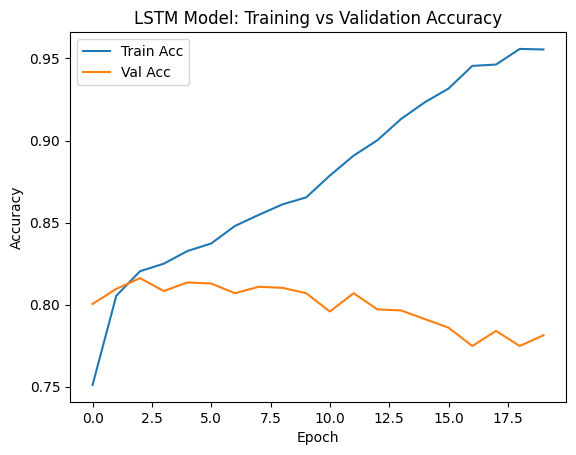

In [19]:
plt.plot(trained_lstm_model.history["accuracy"], label="Train Acc")
plt.plot(trained_lstm_model.history["val_accuracy"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("LSTM Model: Training vs Validation Accuracy")
plt.show()

### LSTM Model Tuning

In an effort to improve the accuracy of the model, some tuning will be attempted. The following hyperparameters were tuned in order to increase preformance.

* Embedding Layer trainable set to True, which allows the tuning the Glove embeddings based off the text
* LSTM Size was tuned to Two stacked BiLSTMs(128 and 64 neurons), which allows more complex patterns and long-term dependencies.
* Return Sequences in the first LSTM, which is needed to pass the full sequence output to the second LSTM for deeper learning
* Dense Layer Size tuned to 128 neurons, which increases model capacity to learn richer feature representations
* Dropout Rate reduced to 0.4, which allows to retain more useful features while preventing overfitting
* Learning Rate decresed to 0.0005, which allows slower learning rate for more stable finer convergence during training.
* EarlyStopping was added to prevent overfitting by stopping training once validation loss stops improving.



In [20]:
lstm_model_tuned = models.Sequential([
    layers.Embedding(input_dim=max_vocab_size, output_dim=embedding_dim, weights=[embedding_matrix], input_length=max_len, trainable=True),
    layers.Bidirectional(layers.LSTM(128, return_sequences=True)),
    layers.Bidirectional(layers.LSTM(64)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(1, activation="sigmoid")
])


early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

lstm_model_tuned.compile(optimizer=Adam(learning_rate=0.0005), loss="binary_crossentropy", metrics=["accuracy"])
lstm_model_tuned.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 1,000,000 (3.81 MB)

 Non-trainable params: 0 (0.00 B)

After tuning the new LSTM model call the fit() method on it to perfrom the training on the model. The training will use the training subset and train over 20 epochs with a batch_size of 32 and use the test subset as validation_data.

In [21]:
trained_lstm_model_tuned = lstm_model_tuned.fit(x_train, y_train, epochs=20, batch_size=32, validation_data=(x_test, y_test), callbacks=[early_stop])

Epoch 1/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.7156 - loss: 0.5589 - val_accuracy: 0.8024 - val_loss: 0.4611
Epoch 2/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.8243 - loss: 0.4035 - val_accuracy: 0.7800 - val_loss: 0.5119
Epoch 3/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.8537 - loss: 0.3576 - val_accuracy: 0.8207 - val_loss: 0.4237
Epoch 4/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.8782 - loss: 0.3086 - val_accuracy: 0.8214 - val_loss: 0.4344
Epoch 5/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.8919 - loss: 0.2825 - val_accuracy: 0.8089 - val_loss: 0.4790
Epoch 6/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.9125 - loss: 0.2307 - val_accuracy: 0.8116 - val_loss: 0.5022


Re-evaluate the accuracy on the testing subset to check if the tuning helped in increasing the accuracy of the model. Based off the accuracy score of 81.9% there was a slight improvement in the model after the tuning althought not by much.

In [22]:
lstm_model_tuned_loss, lstm_model_tuned_acc = lstm_model_tuned.evaluate(x_test, y_test, verbose=2)

print(f"Test Acc: {lstm_model_tuned_acc:.3f}")

48/48 - 0s - 10ms/step - accuracy: 0.8207 - loss: 0.4237
Test Acc: 0.821


Plot the Training vs Validation Accuracy Plot

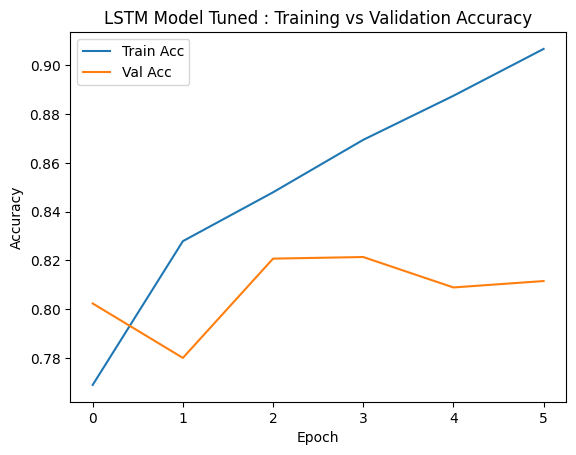

In [23]:
plt.plot(trained_lstm_model_tuned.history["accuracy"], label="Train Acc")
plt.plot(trained_lstm_model_tuned.history["val_accuracy"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("LSTM Model Tuned : Training vs Validation Accuracy")
plt.show()

### GRU Model Architecture

The second model I decided to try was a Gated Recurrent Unit (GRU) it is often used because it is simpler, faster model than a LSTM model, while still effectively capturing sequential dependencies. The GRU model built for this project consists of the following layers:

1. Embedding Layer

    * Maps each word index into a dense vector
    * input_dim set to 10,000 (size of the vocabulary)
    * output_dim set to 100 (each word is mapped to 100 dim GloVe embeddings)
    * weights set to embedding_matrix (initialized with Glove emeddings)
    * input_length set to 100 (each input tweet is padded or truncted to 100 tokens)
    * trainable set to False (embedding weights are frozen to preserve the semantic knowledge from the Glove)

2. Bidirectional GRU Layer

    * Processes the input sequence from both forward and backward directions to better capture contextual relationships
    * 64 GRU neurons

3. Dense Fully Connected Layer

    * Learns higher-level abstract features from the GRU outputs
    * 64 neurons
    * Relu activation function to introduce non-linearity

4. Dropout Layer

    * Helps prevent overfitting by randomly dropping 50% of the neurons during training
    * rate set 0.5

5. Output Dense Layer

    * Outputs the final prediction for binary classification
    * 1 nueron
    * Sigmoid activation function to produce between 0 and 1


In [24]:
gru_model = models.Sequential([
    layers.Embedding(input_dim=max_vocab_size, output_dim=embedding_dim, weights=[embedding_matrix], input_length=max_len, trainable=False),
    layers.Bidirectional(layers.GRU(64)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

gru_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

gru_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,000,000 (3.81 MB)

After creating the GRU model call the fit() method on it to perfrom the training on the model. The training will use the training subset and train over 20 epochs with a batch_size of 32 and use the test subset as validation_data.

In [25]:
gru_model_trained = gru_model.fit(x_train, y_train, epochs=20, batch_size=32, validation_data=(x_test, y_test))

Epoch 1/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6959 - loss: 0.5824 - val_accuracy: 0.8056 - val_loss: 0.4543
Epoch 2/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8039 - loss: 0.4501 - val_accuracy: 0.7912 - val_loss: 0.4486
Epoch 3/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8258 - loss: 0.4036 - val_accuracy: 0.7997 - val_loss: 0.4304
Epoch 4/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8253 - loss: 0.4129 - val_accuracy: 0.8089 - val_loss: 0.4136
Epoch 5/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8190 - loss: 0.4117 - val_accuracy: 0.8194 - val_loss: 0.4289
Epoch 6/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8377 - loss: 0.3835 - val_accuracy: 0.8089 - val_loss: 0.4361
Epoch 7/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8384 - loss: 0.3685 - val_accuracy: 0.8063 - val_loss: 0.4277
Epoch 8/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8505 - loss: 0.3561 - val_accu

After training the model the next step is to evaluate the performance of the trained model by using the test subset to score the accuracy of the model. The accuary of the model resulted in an accuracy score of about 78.5%. Which is a higher than the base LSTM accuracy score but slightly lower than the tuned LSTM model.

In [26]:
gru_model_loss, gru_model_acc = gru_model.evaluate(x_test, y_test, verbose=2)

print(f"Test Acc: {gru_model_acc:.3f}")

48/48 - 0s - 4ms/step - accuracy: 0.7853 - loss: 0.8265
Test Acc: 0.785


Plot the Training vs Validation Accuracy Plot

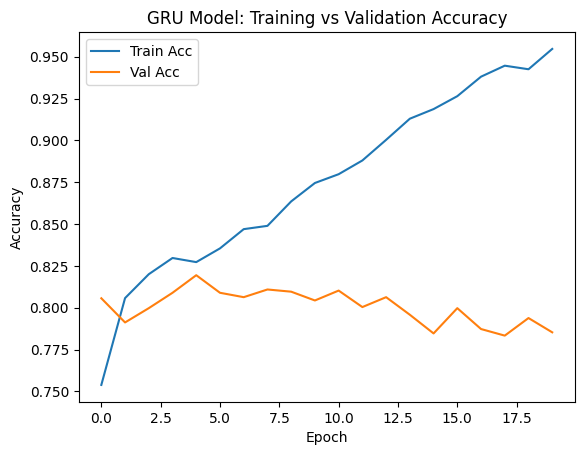

In [27]:
plt.plot(gru_model_trained.history["accuracy"], label="Train Acc")
plt.plot(gru_model_trained.history["val_accuracy"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("GRU Model: Training vs Validation Accuracy")
plt.show()

### GRU Model Tuning

In an effort to improve the accuracy of the model, some tuning will be attempted. The following hyperparameters were tuned in order to increase preformance.

* Embedding Layer updated trainable parameter to True, which allows the Glove embeddings to fine-tune during training.
* GRU Size was increased to 2 stacked BiGRUs (128 and 64 nuerons), which allows the model's capacity to learn more complex, hierarchial features.
* GRU return squences in the first GRU was updated to True, which allows for passing the full sequence output to the next GRU layer, enabling deeper sequential feature extraction.
* Dropout rate was decreased to 0.4, which allows the dropout to retain more features while avoding overfitting.
* Learning Rate was lowered to 0.0005, whihc leads to more stable, gradual updates, helping the model converage better without overshooting minima.

In [28]:
gru_model_tuned = models.Sequential([
    layers.Embedding(input_dim=max_vocab_size, output_dim=embedding_dim, weights=[embedding_matrix], input_length=max_len, trainable=True),
    layers.Bidirectional(layers.GRU(128, return_sequences=True)),
    layers.Bidirectional(layers.GRU(64)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(1, activation="sigmoid")
])


early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

gru_model_tuned.compile(optimizer=Adam(learning_rate=0.0005), loss="binary_crossentropy", metrics=["accuracy"])
gru_model_tuned.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 1,000,000 (3.81 MB)

 Non-trainable params: 0 (0.00 B)

Re-evaluate the accuracy on the testing subset to check if the tuning helped in increasing the accuracy of the model. Based off the accuracy score of 81.4% there was a slight improvement in the model after the tuning althought not by much.

In [29]:
trained_gru_model_tuned = gru_model_tuned.fit(x_train, y_train, epochs=20, batch_size=32, validation_data=(x_test, y_test), callbacks=[early_stop])

Epoch 1/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.7173 - loss: 0.5612 - val_accuracy: 0.8050 - val_loss: 0.4369
Epoch 2/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.8250 - loss: 0.4099 - val_accuracy: 0.8188 - val_loss: 0.4155
Epoch 3/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.8568 - loss: 0.3563 - val_accuracy: 0.8194 - val_loss: 0.4178
Epoch 4/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.8784 - loss: 0.3108 - val_accuracy: 0.8109 - val_loss: 0.4346
Epoch 5/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.8987 - loss: 0.2611 - val_accuracy: 0.8129 - val_loss: 0.4521


In [30]:
gru_model_tuned_test_loss, gru_model_tuned_test_acc = gru_model_tuned.evaluate(x_test, y_test, verbose=2)

print(f"Test Acc: {gru_model_tuned_test_acc:.3f}")

48/48 - 0s - 8ms/step - accuracy: 0.8188 - loss: 0.4155
Test Acc: 0.819


Plot the Training vs Validation Accuracy Plot

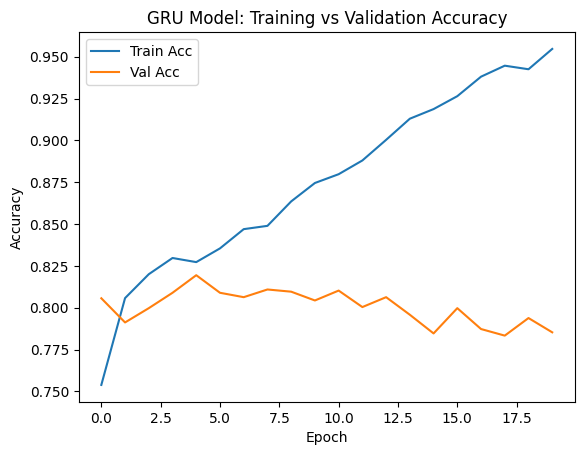

In [31]:
plt.plot(gru_model_trained.history["accuracy"], label="Train Acc")
plt.plot(gru_model_trained.history["val_accuracy"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("GRU Model: Training vs Validation Accuracy")
plt.show()

In order to visually see how well each model performed a bar plot of all the model accuracies was created. The bar plot shows that the tuned LSTM model prfomed the best but the tuned GRU model is right behind it. The worst performing model was the intial LTMS model.

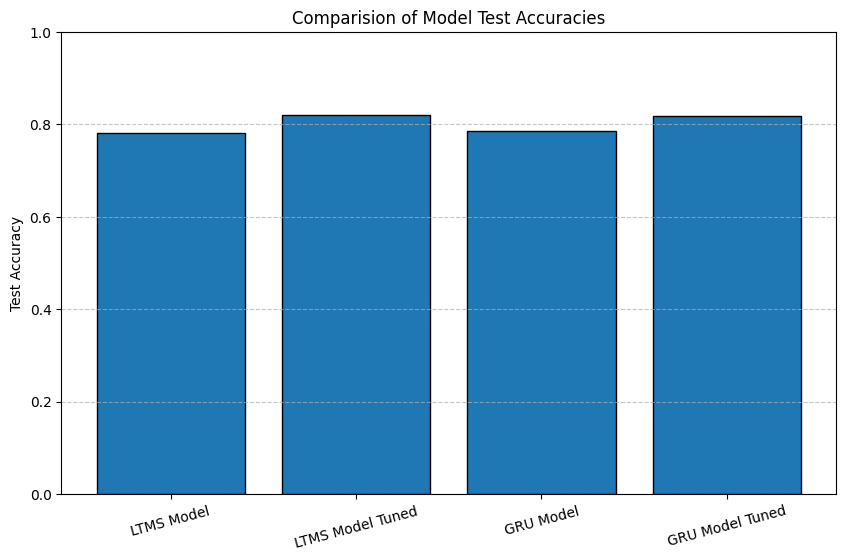

In [32]:
model_accs = [lstm_model_acc, lstm_model_tuned_acc, gru_model_acc, gru_model_tuned_test_acc]

model_names = ["LTMS Model", "LTMS Model Tuned", "GRU Model", "GRU Model Tuned"]

plt.figure(figsize=(10, 6))
plt.bar(model_names, model_accs, edgecolor="black")
plt.ylim(0, 1)
plt.ylabel("Test Accuracy")
plt.title("Comparision of Model Test Accuracies")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=15)
plt.show()

### Kaggle Results

Now the the models have been trained and tuned they will be used to predict the tragets for a separate test dataset. The dataset is loaded and the first 5  rows are displayed below.


In [33]:
test_dataset = pd.read_csv(test_dataset_path, index_col=False)

display(test_dataset.head())

,id,keyword,location,text
0,0,NaN,NaN,Just happened a terrible car crash
1,2,NaN,NaN,"Heard about #earthquake is different cities, s..."
2,3,NaN,NaN,"there is a forest fire at spot pond, geese are..."
3,9,NaN,NaN,Apocalypse lighting. #Spokane #wildfires
4,11,NaN,NaN,Typhoon Soudelor kills 28 in China and Taiwan


Extract the text values from the dataframe, and use the same tokenizer object from the inital data preprocssing to convert the new test tweets into sequences and then pad them.

In [34]:
new_test_texts = test_dataset["text"].values

new_test_sequences = tokenizer.texts_to_sequences(new_test_texts)

new_padded = pad_sequences(new_test_sequences, maxlen=max_len, padding="post", truncating="post")


The following code blocks will call each model that was trained and use the new testing dataset to predect the labels and create a pandas dataframe.

In [35]:
preds_lstm_model = lstm_model.predict(new_padded)
pred_targets_lstm_model = (preds_lstm_model > 0.5).astype(int)
lstm_model_results = pd.DataFrame(test_dataset["id"])
lstm_model_results["target"] = pred_targets_lstm_model

102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [36]:
preds_lstm_model_tuned = lstm_model_tuned.predict(new_padded)
pred_targets_lstm_model_tuned = (preds_lstm_model_tuned > 0.5).astype(int)
lstm_model_tuned_results = pd.DataFrame(test_dataset["id"])
lstm_model_tuned_results["target"] = pred_targets_lstm_model_tuned

102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


In [41]:
preds_gru_model = gru_model.predict(new_padded)
pred_targets_gru_model = (preds_gru_model > 0.5).astype(int)
gru_model_results = pd.DataFrame(test_dataset["id"])
gru_model_results["target"] = pred_targets_gru_model

102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [38]:
preds_gru_model_tuned = gru_model_tuned.predict(new_padded)
pred_targets_gru_model_tuned = (preds_gru_model_tuned > 0.5).astype(int)
gru_model_tuned_results = pd.DataFrame(test_dataset["id"])
gru_model_tuned_results["target"] = pred_targets_gru_model_tuned

102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


After all the models have predicted and created a pandas dataframe the dataframe will be saved locally as a csv. The csv will be submitted to kaggle for scoring.

In [42]:
preds_path = os.path.join(os.getcwd(), "model_preds")

lstm_model_results.to_csv(os.path.join(preds_path, "lstm_model_1.csv"), index=False)
lstm_model_tuned_results.to_csv(os.path.join(preds_path, "lstm_model_1_tuned.csv"), index=False)
gru_model_results.to_csv(os.path.join(preds_path, "gru_model_2.csv"), index=False)
gru_model_tuned_results.to_csv(os.path.join(preds_path, "gru_model_2_tuned.csv"), index=False)

### The follwing screenshots shows the results of each model on Kaggel. Surprisingly tuned GRU model perfomed the best but only slightly, while the tuned LSTM scored the highest on the validation subset of test data.

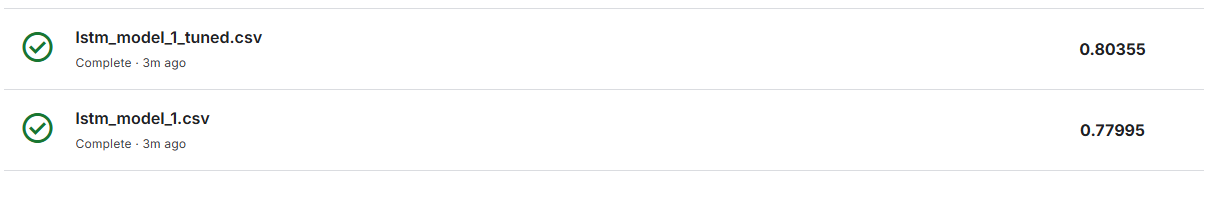

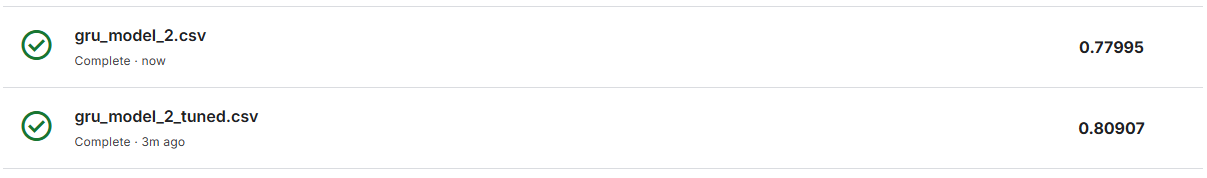

### Conclusion

In this project, I explored building and tuning Recurrent Neural Network models to classify disaster-related tweets. Specifically, I implemented both, LSTM-based and GRU-based models, along with tuned versions of each architecture. After tuning, both models demonstrated imporoved performance compared to their original untuned models. The best performing model was LSTM, which achieved beter accuracy than the tuned GRU model. This suggests that the LSTM's more complex gating mechanisms were beneficial for capturing the nuances in disaster-related tweet sequences. In the future I would like to apply more tuning to the models and possible attempt to train a model on a GPU instead of a CPU.


### Refrences

1. [Tensorflow Docs](https://www.tensorflow.org/api_docs/python/tf/all_symbols)
2. [Keras API Docs](https://keras.io/api/)
3. [Tensorflow CNN Tutorial](https://www.tensorflow.org/tutorials/images/cnn)
4. [Pre-Trained GloVe](https://nlp.stanford.edu/projects/glove/)
5. [Example Implmentation of LTMS](https://machinelearningmastery.com/time-series-prediction-lstm-recurrent-neural-networks-python-keras/)
6. [Example Implmentation of GRU](https://sharmasaravanan.medium.com/time-series-forecasting-using-gru-a-step-by-step-guide-b537dc8dcfba)
7. [Pre-Trained Word Embedding Example](https://www.geeksforgeeks.org/pre-trained-word-embedding-using-glove-in-nlp-models/)

### Github Repo

https://github.com/charliearvizu-edu/nlp_tweets/tree/dev